**Author:** Joseph Williams

**Original Version:** November 2025

**Updated:** September 2026 — expanded to a leak-free pipeline workflow with
cross-validation, additional model families, threshold tuning, and SHAP-based
interpretability

**Dataset Source:** [Kaggle - Heart Failure Diagnosis Data](https://www.kaggle.com/datasets/alamshihab075/heart-failure-diagnosis-data-for-machine-learning)

---


# Cardiovascular Disease Prediction Using Machine Learning


## Project Overview

**Problem Statement**

Cardiovascular disease (CVD) is one of the leading causes of death globally. Early detection through routine health metrics could enable preventive interventions and improve patient outcomes. This project explores whether machine learning can effectively predict CVD presence based on commonly collected patient health data.

**Objectives**

- Build and evaluate binary classification models spanning several algorithm families: linear (Logistic Regression), probabilistic (Naive Bayes), instance-based (KNN), tree-based (Decision Tree, Random Forest, XGBoost), and neural network (MLP)
- Use `scikit-learn` Pipelines so feature engineering and scaling are fit only on training folds, preventing data leakage
- Tune every model with cross-validated hyperparameter search rather than a single train/test split
- Compare models on multiple metrics (ROC-AUC, PR-AUC, F1/F2, calibration), not accuracy alone
- Tune the classification threshold to reflect the cost of a missed diagnosis versus a false alarm
- Evaluate the final model's stability (bootstrap confidence intervals) and fairness across demographic subgroups
- Explain the final model's predictions with permutation importance and SHAP

**Dataset**

This analysis uses the ["Heart Failure Diagnosis Data for Machine Learning"](https://www.kaggle.com/datasets/alamshihab075/heart-failure-diagnosis-data-for-machine-learning) dataset from Kaggle: 70,000 patient records with 11 health features and a binary CVD diagnosis label.

**Approach**

1. Data exploration and quality assessment
2. Rule-based data cleaning of physiologically implausible values
3. Domain-driven feature engineering (BMI, pulse pressure, mean arterial pressure)
4. Stratified train/test split, with the test set touched only once, at the end
5. Cross-validated training and hyperparameter tuning across 8 model families plus a stacking ensemble
6. Threshold tuning for the medical-screening cost trade-off
7. Comprehensive final evaluation: confidence intervals, calibration, and subgroup fairness
8. Interpretability with permutation importance and SHAP


## 0. Setup


In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import (
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_validate,
    train_test_split,
)

from cardio.config import MODELS_DIR, RANDOM_STATE, RESULTS_DIR
from cardio.data import clean_data, load_data, split_features_target
from cardio.evaluation import (
    CV_SCORING,
    bootstrap_metric_ci,
    compute_metrics,
    cv_comparison_table,
    plot_calibration,
    plot_confusion_matrix,
    plot_cvd_distribution,
    plot_pr_curves,
    plot_roc_curves,
    print_statement_header,
    select_final_model,
    subgroup_report,
    tune_model,
)
from cardio.explain import (
    linear_shap_summary,
    permutation_importance_table,
    shap_waterfall_for_index,
    tree_shap_summary,
)
from cardio.models import COMPLEXITY_ORDER, build_stacking_pipeline, get_model_specs

set_config(display="diagram")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


## 1. Data Loading and Exploration


In [2]:
# Read in data from csv file
heart_failure = load_data()

# Display first and last 5 rows
display(heart_failure.head())
display(heart_failure.tail())


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0
1,1,20228,1,156,85,140,90,3,1,0,0,1,1
2,2,18857,1,165,64,130,70,3,1,0,0,0,1
3,3,17623,2,169,82,150,100,1,1,0,0,1,1
4,4,17474,1,156,56,100,60,1,1,0,0,0,0


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72,120,80,2,1,0,0,1,0


### 1.1 Descriptive statistics

Before building anything, we look at the shape, types, and summary statistics of every column.


In [3]:
print_statement_header("Dataframe Shape")
print(f"Num of columns: {heart_failure.shape[1]}")
print(f"Num of rows: {heart_failure.shape[0]}")

print_statement_header("Descriptive Statistics")
print(heart_failure.describe())

print_statement_header("Missing Values")
print(heart_failure.isna().sum())



Dataframe Shape
Num of columns: 13
Num of rows: 70000

Descriptive Statistics
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.349571    164.359229     74.205543   
std    28851.302323   2467.251667      0.476838      8.210126     14.395829   
min        0.000000  10798.000000      1.000000     55.000000     10.000000   
25%    25006.750000  17664.000000      1.000000    159.000000     65.000000   
50%    50001.500000  19703.000000      1.000000    165.000000     72.000000   
75%    74889.250000  21327.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean     128.817714     96.630414      1.366871    

**Something looks wrong.** `ap_lo` (diastolic blood pressure) has a *higher* mean (96.6) than a
healthy diastolic reading should, a standard deviation of 188, and a minimum of -70. `ap_hi`
(systolic) ranges from -150 to 16,020. `height` goes as low as 55 cm and `weight` as low as 10 kg.
These are data-entry errors (some patients' values look transposed or mistyped), not real patients.
The original version of this notebook fed these values straight into the models; we clean them
first, in Section 2.


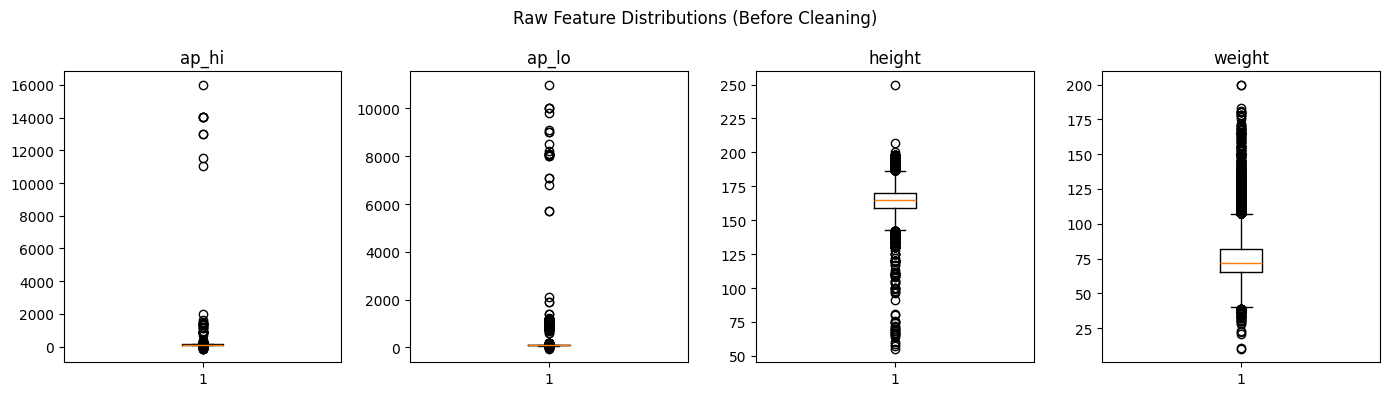

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axs, ["ap_hi", "ap_lo", "height", "weight"]):
    ax.boxplot(heart_failure[col], vert=True)
    ax.set_title(col)
fig.suptitle("Raw Feature Distributions (Before Cleaning)")
fig.tight_layout()
plt.show()


## 2. Data Cleaning

We drop duplicate records and rows with physiologically implausible values, using fixed clinical
bounds (see `cardio.config.PLAUSIBLE_RANGES`) rather than anything learned from the data. Because
the rules are fixed thresholds, applying this before the train/test split does not leak information
between the two sets.

- `ap_hi` (systolic) outside 80-250 mmHg
- `ap_lo` (diastolic) outside 40-160 mmHg, or `ap_lo >= ap_hi`
- `height` outside 120-220 cm
- `weight` outside 30-200 kg


In [5]:
heart_failure_clean, cleaning_report = clean_data(heart_failure)

print_statement_header("Cleaning Report")
display(cleaning_report)

print(
    f"\nRows before cleaning: {len(heart_failure):,}"
    f"\nRows after cleaning:  {len(heart_failure_clean):,}"
)



Cleaning Report


,Rule,Rows Dropped,% of Original
0,Duplicate record,24,0.034286
1,"ap_hi outside [80, 250]",247,0.352857
2,"ap_lo outside [40, 160]",1007,1.438571
3,"height outside [120, 220]",50,0.071429
4,"weight outside [30, 200]",6,0.008571
5,ap_lo >= ap_hi,82,0.117143
6,Total,1416,2.022857



Rows before cleaning: 70,000
Rows after cleaning:  68,584


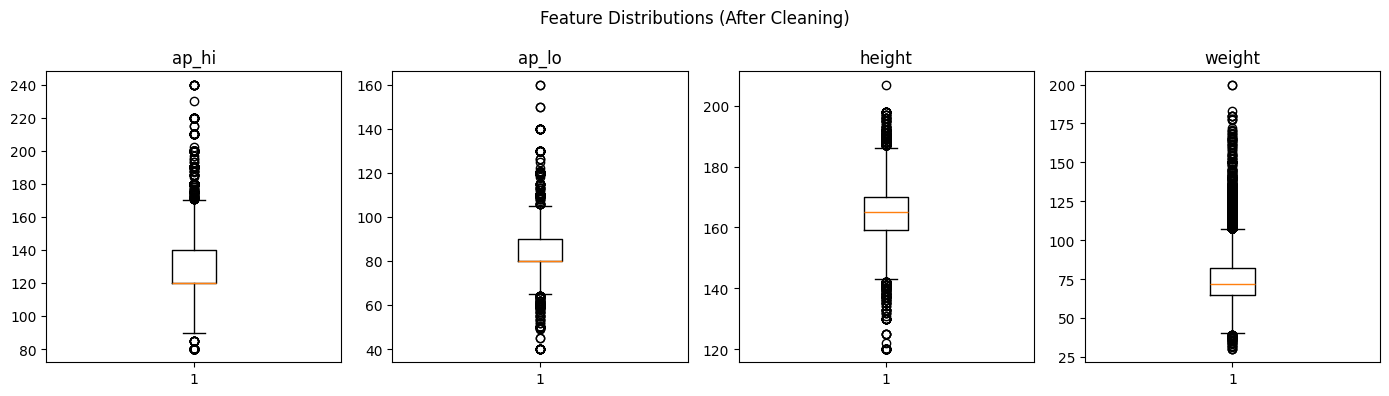

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axs, ["ap_hi", "ap_lo", "height", "weight"]):
    ax.boxplot(heart_failure_clean[col], vert=True)
    ax.set_title(col)
fig.suptitle("Feature Distributions (After Cleaning)")
fig.tight_layout()
plt.show()


## 3. Target Variable Analysis

**Understanding Class Balance**

In medical classification problems, class balance significantly impacts model performance and
interpretation. An imbalanced dataset (e.g., 95% healthy, 5% CVD) creates challenges:
- Models may achieve high accuracy by simply predicting the majority class
- Rare but critical cases (actual CVD patients) could be systematically missed
- Evaluation metrics like accuracy become misleading

We verify our cleaned dataset still has adequate representation of both classes.


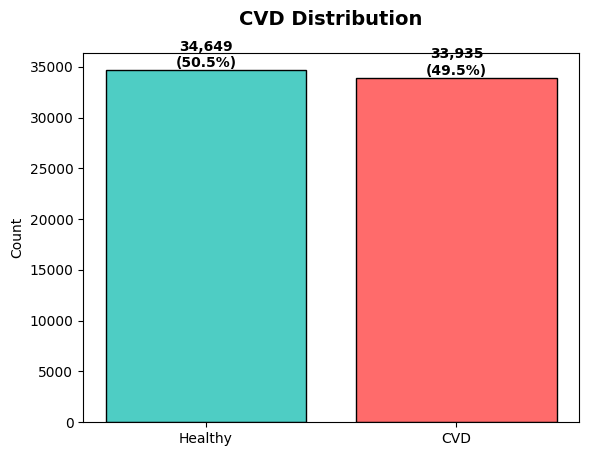

In [7]:
plot_cvd_distribution(heart_failure_clean["cardio"])


## 4. Feature Engineering

We derive a few clinically meaningful features from the raw columns, implemented in
`cardio.features.add_engineered_features`:

- **`age_years`** — age converted from days to years (`age / 365.25`)
- **`bmi`** — body mass index, `weight (kg) / height (m)^2`
- **`pulse_pressure`** — `ap_hi - ap_lo`, the difference between systolic and diastolic pressure
- **`map`** — mean arterial pressure, `(ap_hi + 2 * ap_lo) / 3`
- **`gender`** — recoded from 1/2 to 0 (female) / 1 (male)

Rather than computing these once on the whole dataset, we wrap the function in a
`FunctionTransformer` and make it the **first step of every model's pipeline** (see
`cardio.preprocessing.build_pipeline`). That way the exact same transformation the model was
trained with is applied automatically at prediction time, on raw patient data, with no risk of
forgetting a step in production.

Here's what it produces, on a few cleaned rows:


In [8]:
from cardio.features import add_engineered_features

add_engineered_features(heart_failure_clean.drop(columns=["id", "cardio"]).head())


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years,bmi,pulse_pressure,map
0,1,168,62,110,80,1,1,0,0,1,50.357290,21.967120,30,90.000000
1,0,156,85,140,90,3,1,0,0,1,55.381246,34.927679,50,106.666667
2,0,165,64,130,70,3,1,0,0,0,51.627652,23.507805,60,90.000000
3,1,169,82,150,100,1,1,0,0,1,48.249144,28.710479,50,116.666667
4,0,156,56,100,60,1,1,0,0,0,47.841205,23.011177,40,73.333333


## 5. Train/Test Split

**The Importance of Proper Data Splitting**

Never train and test a model on the same data. This is analogous to memorizing exam questions
rather than learning concepts — the model would achieve artificially high performance that doesn't
generalize to new patients.

**Our Approach**

- **80% Training Set**: used for cross-validated hyperparameter tuning
- **20% Test Set**: touched exactly once, at the very end, to report final performance
- **Stratification**: keeps the CVD/healthy ratio the same in both sets

Compared to the original 70/30 split, we can afford a larger training set now that model selection
happens by cross-validation rather than by repeatedly checking the test set.


In [9]:
heart_failure_features, heart_failure_target = split_features_target(heart_failure_clean)

X_train, X_test, y_train, y_test = train_test_split(
    heart_failure_features,
    heart_failure_target,
    test_size=0.2,
    stratify=heart_failure_target,
    random_state=RANDOM_STATE,
)

print_statement_header("Split Sizes")
print(f"Training set: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"Test set:     {X_test.shape[0]:,} rows, {X_test.shape[1]} columns")



Split Sizes
Training set: 54,867 rows, 11 columns
Test set:     13,717 rows, 11 columns


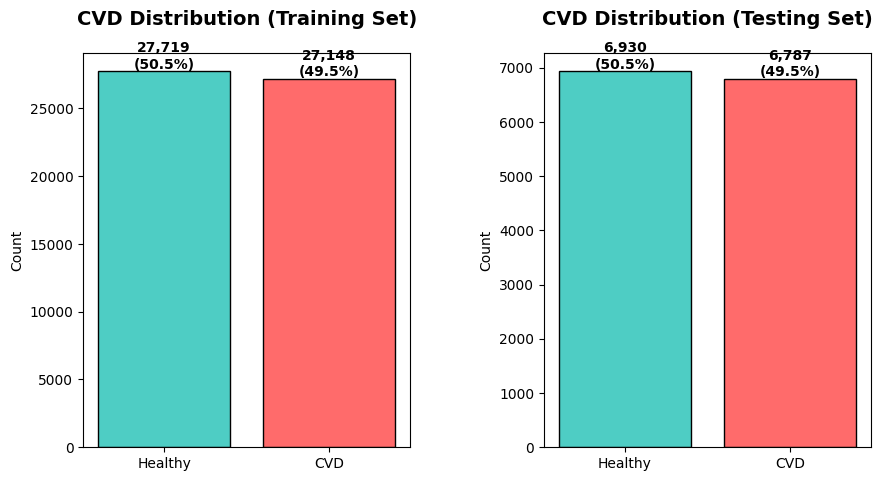

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))
plot_cvd_distribution(y_train, axs[0], "CVD Distribution (Training Set)")
plot_cvd_distribution(y_test, axs[1], "CVD Distribution (Testing Set)")
fig.tight_layout(pad=5)
plt.show()


## 6. Pipelines and Preprocessing

**Why put everything in a `Pipeline`?**

In the original version of this project, `StandardScaler` was fit once on `X_train` and reused for
every model. That's fine for a single split, but as soon as cross-validation enters the picture, it
becomes a leakage risk: each CV fold needs its *own* scaler, fit only on that fold's training rows,
or information from a validation fold leaks into the transformation.

`cardio.preprocessing.build_pipeline` bundles three steps behind a single `.fit()`/`.predict()`
interface:

1. **Feature engineering** — the `FunctionTransformer` from Section 4
2. **Preprocessing** — a `ColumnTransformer` that standardizes continuous columns (for
   distance/gradient-based models) and passes ordinal/binary columns through unchanged; tree-based
   models skip scaling entirely since it doesn't affect their splits
3. **Model** — the classifier itself

`scikit-learn`'s cross-validation tools re-fit the *entire* pipeline on each fold, so scaling and
feature engineering are always computed from that fold's training data alone.


In [11]:
from cardio.preprocessing import build_pipeline

example_pipeline = build_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
example_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x7f860030fa60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function _na...x7f860030fba0>
,"kw_args kw_args: dict, default=NoneDictionary of addit

## 7. Baseline Models

We start with four fast, simple baselines before moving to more expensive models:

- **Dummy (stratified)**: predicts randomly according to the class distribution. This is our floor
  — any model that can't beat it isn't learning anything useful.
- **Logistic Regression**: a linear baseline; the top performer in the original version of this
  project.
- **Gaussian Naive Bayes**: assumes features are independent given the class; very fast, sometimes
  surprisingly competitive.
- **Decision Tree**: a single tree, before we add ensembles of them.

Every model is tuned with `StratifiedKFold(5)` cross-validation on the training set only, scored on
several metrics at once (`cardio.evaluation.CV_SCORING`), and selected by mean CV ROC-AUC.


In [12]:
model_specs = get_model_specs()
baseline_names = [
    "Dummy (stratified)",
    "Logistic Regression",
    "Gaussian Naive Bayes",
    "Decision Tree",
]

searches = {}
for name in baseline_names:
    print_statement_header(f"Tuning: {name}")
    searches[name] = tune_model(model_specs[name], X_train, y_train)
    best = searches[name]
    idx = best.best_index_
    print(f"Best CV ROC-AUC: {best.cv_results_['mean_test_roc_auc'][idx]:.4f}")
    if best.best_params_:
        print(f"Best params: {best.best_params_}")



Tuning: Dummy (stratified)


Best CV ROC-AUC: 0.4995

Tuning: Logistic Regression


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/li

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/li

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/li

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/li

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and us

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/li

/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best CV ROC-AUC: 0.7918
Best params: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'saga'}

Tuning: Gaussian Naive Bayes


Best CV ROC-AUC: 0.7845
Best params: {'model__var_smoothing': 0.001}

Tuning: Decision Tree


Best CV ROC-AUC: 0.7930
Best params: {'model__max_depth': 6, 'model__min_samples_leaf': 50}


## 8. Additional Models

Now the models the original project's "Future Work" section called for:

- **K-Nearest Neighbors**: revisited with a much wider search over `k` (5-101) and distance
  weighting, instead of manually comparing `k=5` vs. `k=9` against the test set.
- **Random Forest**: an ensemble of decision trees, usually far more robust than a single tree.
- **XGBoost**: gradient-boosted trees, typically the strongest performer on tabular data like this.
- **Neural Network (MLP)**: a small multilayer perceptron, to check whether a more flexible
  non-linear model captures anything the tree ensembles miss.

These have larger search spaces, so we use `RandomizedSearchCV` rather than an exhaustive grid.
This cell takes a few minutes to run.


In [13]:
extended_names = [
    "K-Nearest Neighbors",
    "Random Forest",
    "XGBoost",
    "Neural Network (MLP)",
]

for name in extended_names:
    print_statement_header(f"Tuning: {name}")
    searches[name] = tune_model(model_specs[name], X_train, y_train)
    best = searches[name]
    idx = best.best_index_
    print(f"Best CV ROC-AUC: {best.cv_results_['mean_test_roc_auc'][idx]:.4f}")
    if best.best_params_:
        print(f"Best params: {best.best_params_}")



Tuning: K-Nearest Neighbors


Best CV ROC-AUC: 0.7962
Best params: {'model__weights': 'uniform', 'model__n_neighbors': 101}

Tuning: Random Forest


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best CV ROC-AUC: 0.8005
Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 25, 'model__max_features': 0.5, 'model__max_depth': 10}

Tuning: XGBoost


Best CV ROC-AUC: 0.8018
Best params: {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}

Tuning: Neural Network (MLP)


Best CV ROC-AUC: 0.8002
Best params: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': 0.0001}


## 9. Cross-Validated Model Comparison

`cv_comparison_table` pulls the mean and standard deviation of every scoring metric, at each
model's best hyperparameters, directly out of its search results.


In [14]:
comparison_table = cv_comparison_table(searches)
comparison_table.sort_values("roc_auc (mean)", ascending=False)


,roc_auc (mean),roc_auc (std),average_precision (mean),average_precision (std),brier_score (mean),brier_score (std),recall (mean),recall (std),f1 (mean),f1 (std),accuracy (mean),accuracy (std)
Model,,,,,,,,,,,,
XGBoost,0.801835,0.003199,0.782897,0.005334,0.180063,0.001465,0.688191,0.004311,0.721027,0.002581,0.736508,0.002139
Random Forest,0.800461,0.003860,0.781521,0.005739,0.180603,0.001739,0.688743,0.006682,0.720429,0.004215,0.735524,0.003266
Neural Network (MLP),0.800157,0.003187,0.780124,0.004916,0.181595,0.001702,0.680822,0.020289,0.717075,0.005464,0.734321,0.002506
K-Nearest Neighbors,0.796184,0.003050,0.773950,0.004312,0.182901,0.001396,0.669331,0.005889,0.711461,0.003795,0.731387,0.002902
Decision Tree,0.793020,0.003611,0.766362,0.005140,0.183270,0.001809,0.660012,0.017968,0.708184,0.006598,0.730986,0.004406
Logistic Regression,0.791782,0.002723,0.771198,0.004744,0.186774,0.001088,0.667342,0.005931,0.708389,0.003584,0.728161,0.002592
Gaussian Naive Bayes,0.784480,0.001927,0.761815,0.004278,0.231127,0.001943,0.617467,0.004566,0.686721,0.003804,0.721253,0.003002
Dummy (stratified),0.499452,0.005756,0.494557,0.002872,0.500410,0.005755,0.486187,0.005836,0.490177,0.005873,0.499590,0.005755


A table of means hides fold-to-fold variability. The box plot below shows the actual per-fold
ROC-AUC scores for each model, extracted from the same `cv_results_`.


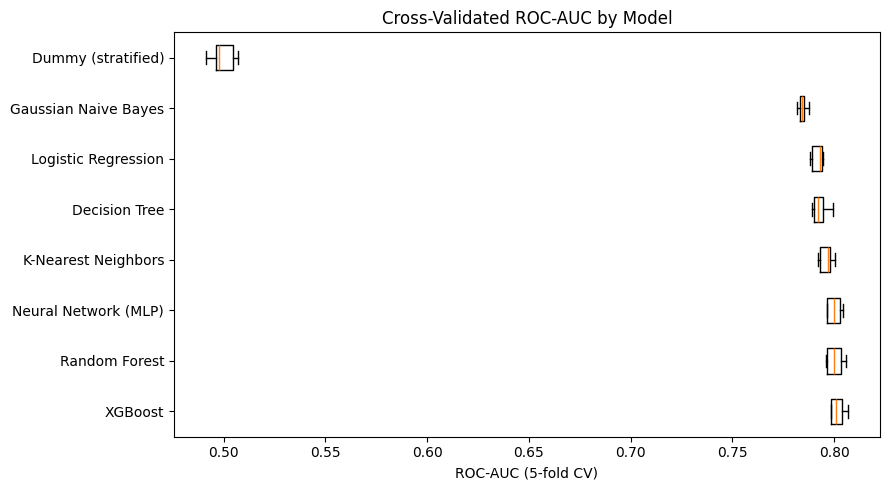

In [15]:
fold_scores = {
    name: [
        search.cv_results_[f"split{i}_test_roc_auc"][search.best_index_]
        for i in range(5)
    ]
    for name, search in searches.items()
}
fold_scores_df = pd.DataFrame(fold_scores)

order = comparison_table["roc_auc (mean)"].sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([fold_scores_df[name] for name in order], tick_labels=order, vert=False)
ax.set_xlabel("ROC-AUC (5-fold CV)")
ax.set_title("Cross-Validated ROC-AUC by Model")
plt.tight_layout()
plt.show()


**Reading this table:** the Dummy baseline should sit at essentially 0.50 ROC-AUC — confirming the
other models are learning real signal. Logistic Regression sets the linear-model bar, as it did in
the original analysis. Whether the tree ensembles or the MLP beat it, and by how much, is exactly
what the table above answers — instead of eyeballing two K values against the test set as the
original version did.


## 10. Stacking Ensemble

As a final candidate, we combine the three strongest models (by mean CV ROC-AUC) into a
`StackingClassifier`: their predicted probabilities become the input features for a Logistic
Regression meta-learner. Each base pipeline keeps tuned hyperparameters and its own preprocessing
(scaled or not); `StackingClassifier` refits every base estimator from scratch inside each CV fold,
so this remains leak-free.


In [16]:
top3_names = comparison_table["roc_auc (mean)"].sort_values(ascending=False).index[:3].tolist()
print(f"Stacking base models: {top3_names}")

top3_pipelines = {name: searches[name].best_estimator_ for name in top3_names}
stacking_pipeline = build_stacking_pipeline(top3_pipelines)

stack_cv = cross_validate(
    stacking_pipeline,
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring=CV_SCORING,
    return_estimator=False,
)

stack_row = {}
for metric, scores in stack_cv.items():
    if not metric.startswith("test_"):
        continue
    key = metric.removeprefix("test_")
    mean, std = np.mean(scores), np.std(scores)
    if key == "neg_brier_score":
        mean, key = -mean, "brier_score"
    stack_row[f"{key} (mean)"] = mean
    stack_row[f"{key} (std)"] = std

comparison_table.loc["Stacking Ensemble"] = stack_row
comparison_table.sort_values("roc_auc (mean)", ascending=False)


Stacking base models: ['XGBoost', 'Random Forest', 'Neural Network (MLP)']


,roc_auc (mean),roc_auc (std),average_precision (mean),average_precision (std),brier_score (mean),brier_score (std),recall (mean),recall (std),f1 (mean),f1 (std),accuracy (mean),accuracy (std)
Model,,,,,,,,,,,,
Stacking Ensemble,0.802186,0.003456,0.783378,0.005434,0.180140,0.001535,0.691469,0.006511,0.721768,0.002634,0.736235,0.002238
XGBoost,0.801835,0.003199,0.782897,0.005334,0.180063,0.001465,0.688191,0.004311,0.721027,0.002581,0.736508,0.002139
Random Forest,0.800461,0.003860,0.781521,0.005739,0.180603,0.001739,0.688743,0.006682,0.720429,0.004215,0.735524,0.003266
Neural Network (MLP),0.800157,0.003187,0.780124,0.004916,0.181595,0.001702,0.680822,0.020289,0.717075,0.005464,0.734321,0.002506
K-Nearest Neighbors,0.796184,0.003050,0.773950,0.004312,0.182901,0.001396,0.669331,0.005889,0.711461,0.003795,0.731387,0.002902
Decision Tree,0.793020,0.003611,0.766362,0.005140,0.183270,0.001809,0.660012,0.017968,0.708184,0.006598,0.730986,0.004406
Logistic Regression,0.791782,0.002723,0.771198,0.004744,0.186774,0.001088,0.667342,0.005931,0.708389,0.003584,0.728161,0.002592
Gaussian Naive Bayes,0.784480,0.001927,0.761815,0.004278,0.231127,0.001943,0.617467,0.004566,0.686721,0.003804,0.721253,0.003002
Dummy (stratified),0.499452,0.005756,0.494557,0.002872,0.500410,0.005755,0.486187,0.005836,0.490177,0.005873,0.499590,0.005755


## 11. Selecting the Final Model

We select by mean CV ROC-AUC, but prefer a simpler model when it's within one standard deviation of
the leader — a small, uncertain gain isn't worth the extra complexity of an ensemble or a black-box
model in a setting where clinicians will want to understand *why* a prediction was made.


In [17]:
final_model_name, within_one_std = select_final_model(comparison_table, COMPLEXITY_ORDER)

print_statement_header("Candidates within 1 std of the best CV ROC-AUC")
display(within_one_std[["roc_auc (mean)", "roc_auc (std)", "accuracy (mean)", "f1 (mean)"]])

print(f"\nBest CV ROC-AUC: {within_one_std.index[0]}")
print(f"Selected final model (simplest within 1 std): {final_model_name}")

if final_model_name == "Stacking Ensemble":
    # cross_validate (above) only fits clones internally per fold; the
    # original stacking_pipeline object itself is still unfitted, so it
    # needs an explicit fit on the full training set before it can be used
    # directly (e.g. for the "default threshold" comparison in Section 13).
    final_pipeline = stacking_pipeline
    final_pipeline.fit(X_train, y_train)
else:
    final_pipeline = searches[final_model_name].best_estimator_



Candidates within 1 std of the best CV ROC-AUC


,roc_auc (mean),roc_auc (std),accuracy (mean),f1 (mean)
Model,,,,
Stacking Ensemble,0.802186,0.003456,0.736235,0.721768
XGBoost,0.801835,0.003199,0.736508,0.721027
Random Forest,0.800461,0.003860,0.735524,0.720429
Neural Network (MLP),0.800157,0.003187,0.734321,0.717075



Best CV ROC-AUC: Stacking Ensemble
Selected final model (simplest within 1 std): Random Forest


## 12. Threshold Tuning

Every model above used the default 0.5 probability threshold to turn a predicted probability into a
"CVD" / "healthy" prediction. In a screening context, missing an actual CVD case (a false negative)
is worse than an unnecessary follow-up test (a false positive), so we tune the threshold to optimize
the **F2 score** (like F1, but weights recall twice as heavily as precision) instead.

`TunedThresholdClassifierCV` searches for the best threshold using out-of-fold predictions on the
training set, then refits the underlying model on the full training set — so, like everything else
so far, the test set stays untouched until the next section.


In [18]:
f2_scorer = make_scorer(fbeta_score, beta=2)

tuned_model = TunedThresholdClassifierCV(
    estimator=clone(final_pipeline),
    scoring=f2_scorer,
    cv=5,
    store_cv_results=True,
    random_state=RANDOM_STATE,
)
tuned_model.fit(X_train, y_train)

print(f"Default threshold: 0.5")
print(f"Tuned threshold (optimizing F2): {tuned_model.best_threshold_:.3f}")


Default threshold: 0.5
Tuned threshold (optimizing F2): 0.172


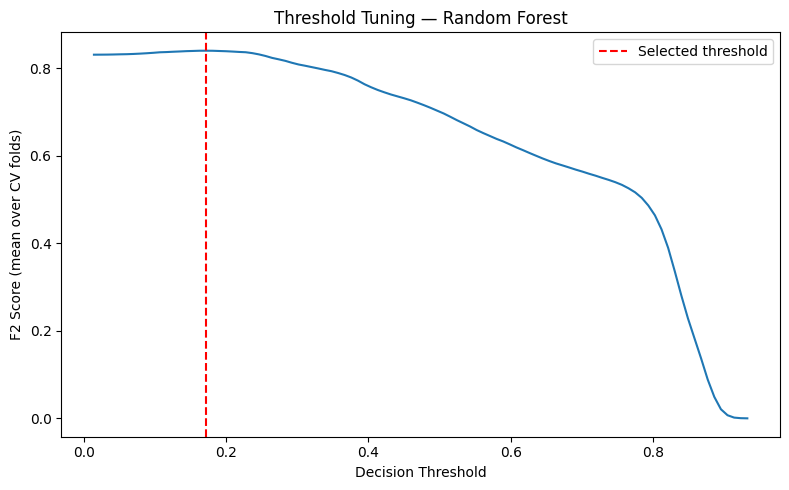

In [19]:
cv_results = tuned_model.cv_results_
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cv_results["thresholds"], cv_results["scores"])
ax.axvline(tuned_model.best_threshold_, color="red", linestyle="--", label="Selected threshold")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("F2 Score (mean over CV folds)")
ax.set_title(f"Threshold Tuning — {final_model_name}")
ax.legend()
plt.tight_layout()
plt.show()


## 13. Final Test Evaluation

This is the **only** section that uses `X_test` / `y_test`. We compare the tuned final model against
its own default-threshold version and against Logistic Regression (the previous best model), then
report bootstrap confidence intervals so we know how much the point estimates could plausibly move
on a different sample of patients.


In [20]:
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
y_pred_tuned = tuned_model.predict(X_test)

y_proba_default = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba_default >= 0.5).astype(int)

y_proba_lr = searches["Logistic Regression"].best_estimator_.predict_proba(X_test)[:, 1]
y_pred_lr = searches["Logistic Regression"].best_estimator_.predict(X_test)

final_metrics = pd.DataFrame(
    {
        f"{final_model_name} (tuned threshold)": compute_metrics(y_test, y_pred_tuned, y_proba_tuned),
        f"{final_model_name} (default threshold)": compute_metrics(y_test, y_pred_default, y_proba_default),
        "Logistic Regression": compute_metrics(y_test, y_pred_lr, y_proba_lr),
    }
)
final_metrics


,Random Forest (tuned threshold),Random Forest (default threshold),Logistic Regression
Accuracy,0.575344,0.731647,0.724138
Balanced Accuracy,0.579504,0.731167,0.723507
Precision,0.539042,0.750727,0.750375
Recall (Sensitivity),0.978488,0.685133,0.663032
Specificity,0.180519,0.777201,0.783983
F1 Score,0.695138,0.716432,0.704005
F2 Score,0.841314,0.697319,0.678835
ROC AUC,0.798406,0.798406,0.788873
PR AUC (Average Precision),0.779457,0.779457,0.768707
Brier Score,0.182065,0.182065,0.188168


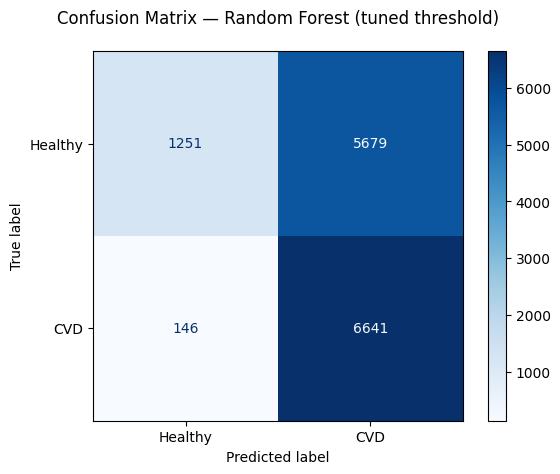

array([[1251, 5679],
       [ 146, 6641]])

In [21]:
plot_confusion_matrix(y_test, y_pred_tuned, title=f"Confusion Matrix — {final_model_name} (tuned threshold)")


### Bootstrap confidence intervals

1,000 bootstrap resamples of the test set give a 95% confidence interval for the two metrics that
matter most in a screening context: ROC-AUC (overall discrimination) and recall/sensitivity (the
fraction of actual CVD cases caught).


In [22]:
from sklearn.metrics import recall_score, roc_auc_score

roc_auc_ci = bootstrap_metric_ci(y_test, y_pred_tuned, y_proba_tuned, roc_auc_score)
recall_ci = bootstrap_metric_ci(
    y_test, y_pred_tuned, None, lambda yt, yp: recall_score(yt, yp)
)

print_statement_header("95% Bootstrap Confidence Intervals")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_tuned):.3f}  (95% CI: {roc_auc_ci[0]:.3f}-{roc_auc_ci[1]:.3f})")
print(f"Recall:   {recall_score(y_test, y_pred_tuned):.3f}  (95% CI: {recall_ci[0]:.3f}-{recall_ci[1]:.3f})")



95% Bootstrap Confidence Intervals
ROC-AUC:  0.798  (95% CI: 0.791-0.806)
Recall:   0.978  (95% CI: 0.975-0.982)


### ROC, precision-recall, and calibration curves


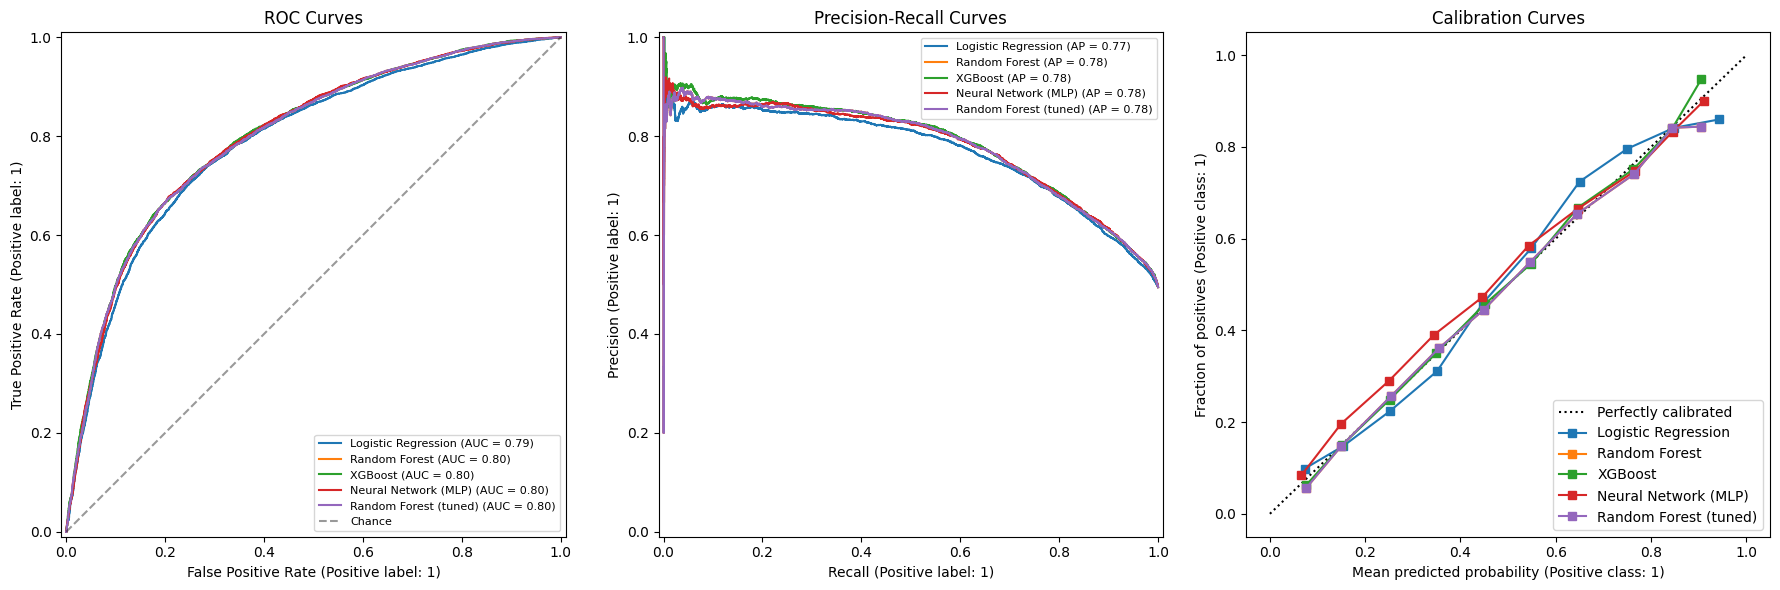

In [23]:
overlay_names = ["Logistic Regression", "Random Forest", "XGBoost", "Neural Network (MLP)"]
models_probas = {
    name: searches[name].best_estimator_.predict_proba(X_test)[:, 1] for name in overlay_names
}
models_probas[f"{final_model_name} (tuned)"] = y_proba_tuned

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
plot_roc_curves(models_probas, y_test, ax=axs[0])
plot_pr_curves(models_probas, y_test, ax=axs[1])
plot_calibration(models_probas, y_test, ax=axs[2])
plt.tight_layout()
plt.show()


### Subgroup fairness check

Aggregate metrics can hide performance gaps between patient groups. We break out the same metrics
by gender and by age band.


In [24]:
subgroup_df = X_test.copy()
subgroup_df["gender"] = subgroup_df["gender"].map({1: "Female", 2: "Male"})
subgroup_df["age_years"] = subgroup_df["age"] / 365.25

print_statement_header("Performance by Gender")
display(subgroup_report(subgroup_df, y_test, y_pred_tuned, y_proba_tuned, group_col="gender"))

print_statement_header("Performance by Age Band")
display(
    subgroup_report(
        subgroup_df,
        y_test,
        y_pred_tuned,
        y_proba_tuned,
        group_col="age_years",
        bins=[0, 45, 55, 150],
        labels=["<45", "45-55", "55+"],
    )
)



Performance by Gender


,Accuracy,Balanced Accuracy,Precision,Recall (Sensitivity),Specificity,F1 Score,F2 Score,ROC AUC,PR AUC (Average Precision),Brier Score,Log Loss,N
Group,,,,,,,,,,,,
Female,0.571701,0.583273,0.531982,0.976879,0.189666,0.688840,0.836899,0.798272,0.767454,0.182260,0.545232,8912
Male,0.582102,0.571964,0.551850,0.981316,0.162612,0.706433,0.849149,0.798183,0.801106,0.181702,0.543015,4805



Performance by Age Band


,Accuracy,Balanced Accuracy,Precision,Recall (Sensitivity),Specificity,F1 Score,F2 Score,ROC AUC,PR AUC (Average Precision),Brier Score,Log Loss,N
Group,,,,,,,,,,,,
45-55,0.507154,0.551653,0.475945,0.982270,0.121037,0.641204,0.809942,0.790826,0.765072,0.179281,0.539471,5661
55+,0.606091,0.502440,0.605615,0.998638,0.006242,0.753984,0.883913,0.729812,0.786728,0.202252,0.590702,6075
<45,0.675921,0.722367,0.468354,0.833622,0.611111,0.599751,0.721139,0.838064,0.720771,0.128112,0.416877,1981


**A single global threshold is not equally fair across subgroups.** At the F2-tuned threshold, patients aged 55+ end up with a specificity of just **0.6%** — almost everyone in that age band gets flagged as high-risk, healthy or not — while patients under 45 keep a far more balanced 61.1% specificity (with 83.4% recall). The model is not necessarily biased in how it scores patients (its ROC-AUC is similar across age bands), but a *single* threshold chosen to optimize aggregate F2 interacts badly with a subgroup whose baseline risk is much higher. A real deployment would need to check calibration and specificity by subgroup before picking one threshold for everyone, or consider a threshold that varies by baseline risk.


## 14. Interpretability

### Permutation importance

A model-agnostic check: how much does the tuned final model's ROC-AUC drop when a single feature's
values are randomly shuffled? A large drop means the model relies heavily on that feature.


In [25]:
importance_table = permutation_importance_table(tuned_model, X_test, y_test)
importance_table


,Feature,Importance (mean),Importance (std)
0,ap_hi,0.182767,0.003039
1,age,0.038181,0.001994
2,cholesterol,0.031143,0.001741
3,weight,0.007785,0.000776
4,ap_lo,0.005505,0.000785
5,gluc,0.001656,0.000285
6,active,0.001482,0.000484
7,height,0.001255,0.000322
8,smoke,0.000463,0.000147
9,alco,0.000199,0.000026


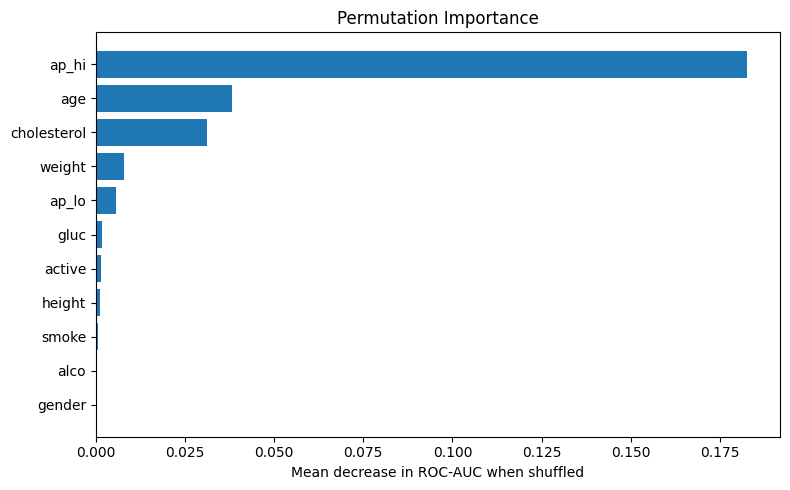

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_table["Feature"][::-1], importance_table["Importance (mean)"][::-1])
ax.set_xlabel("Mean decrease in ROC-AUC when shuffled")
ax.set_title("Permutation Importance")
plt.tight_layout()
plt.show()


### SHAP: tree model vs. linear model

Regardless of which model was ultimately selected above, it's worth contrasting how a tree ensemble
and a linear model "think." We use SHAP's `TreeExplainer` on the tuned XGBoost pipeline and
`LinearExplainer` on the tuned Logistic Regression pipeline, both evaluated on a sample of the test
set for speed.


/home/joseph/Documents/coding-projects/cardio-ml-predictor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


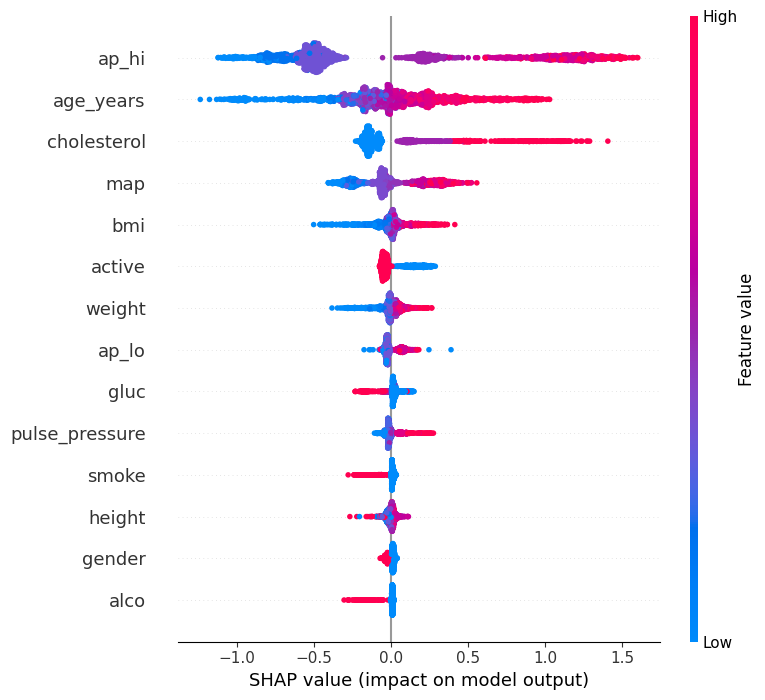

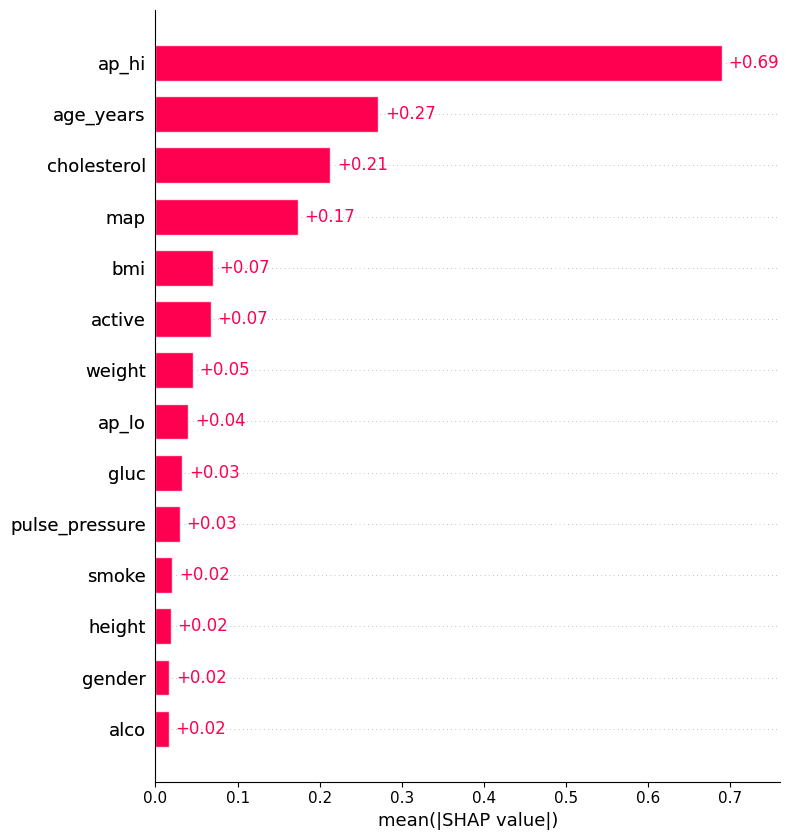

In [27]:
shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)

xgb_pipeline = searches["XGBoost"].best_estimator_
xgb_shap_values, xgb_transformed = tree_shap_summary(xgb_pipeline, shap_sample)


Background dataset has 54867 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=54867 when initializing the masker.


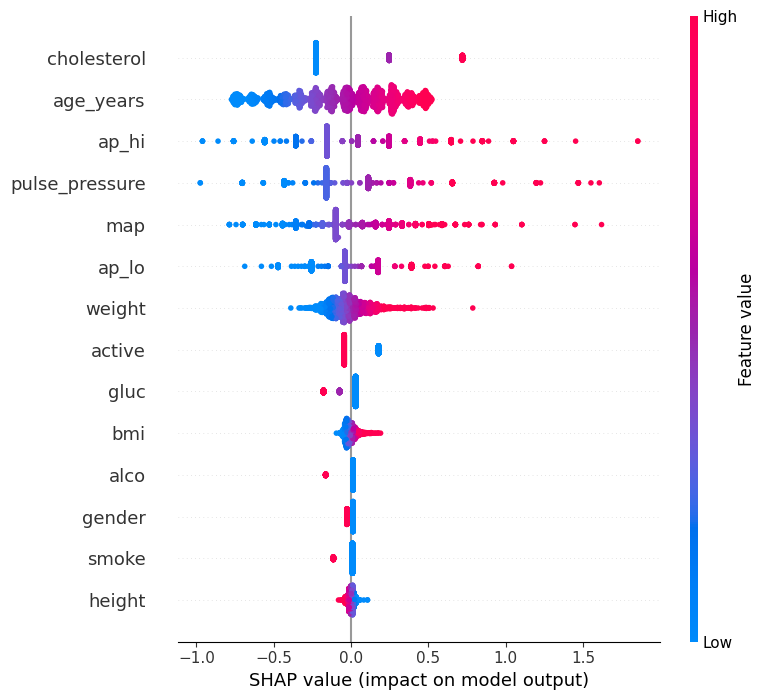

In [28]:
lr_pipeline = searches["Logistic Regression"].best_estimator_
lr_shap_values, lr_transformed = linear_shap_summary(lr_pipeline, X_train, shap_sample)


The two summaries should broadly agree on *which* features matter (blood pressure, age,
cholesterol), which is reassuring — but the XGBoost beeswarm plot can reveal non-linear or
interaction effects the linear model's coefficients cannot.

Finally, two worked examples from the XGBoost model: a true positive (a CVD case it caught) and a
false negative (a CVD case it missed), and which features pushed the prediction each way.


True positive example:


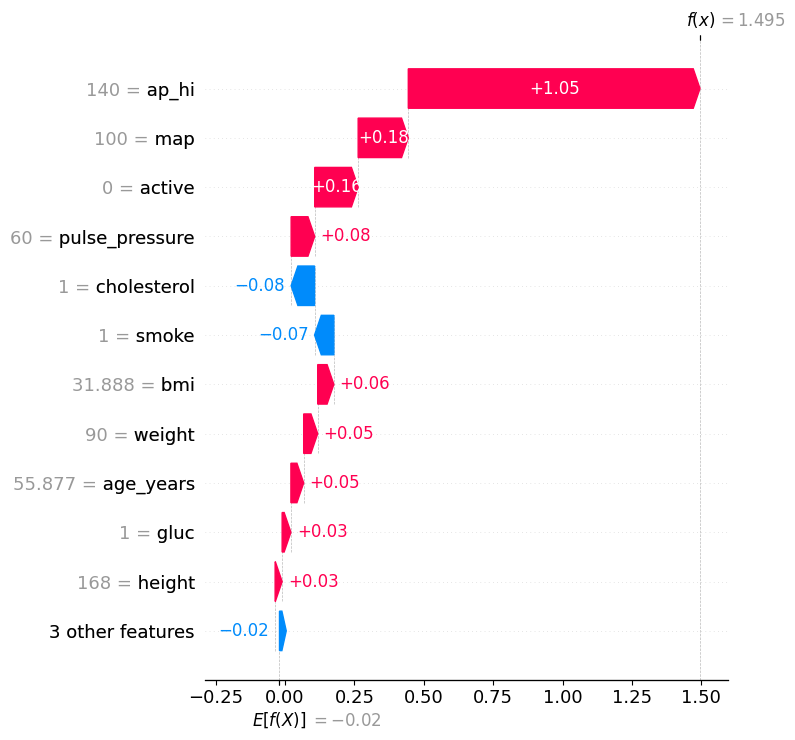

False negative example:


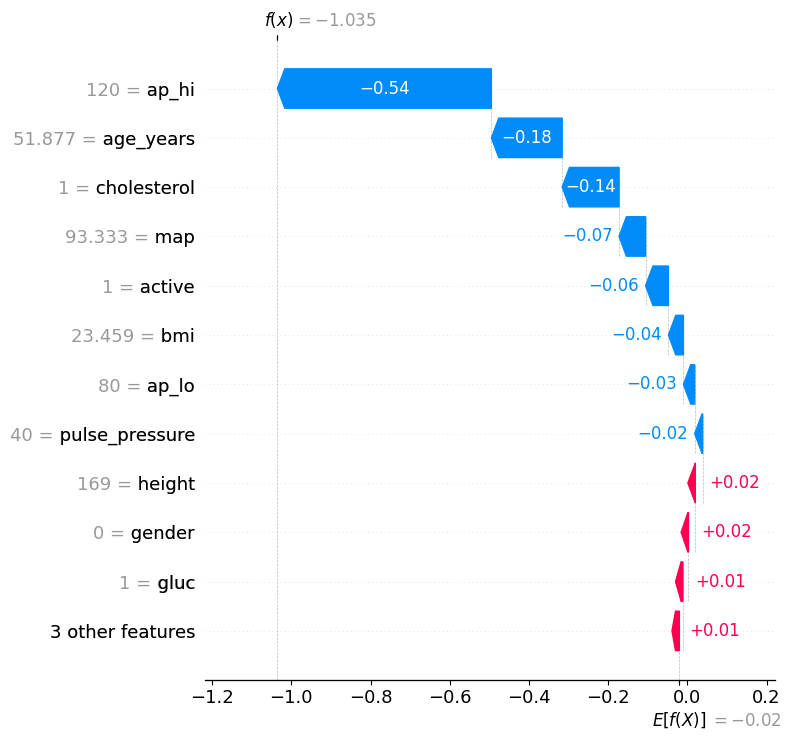

In [29]:
xgb_pred = xgb_pipeline.predict(shap_sample)
xgb_true = y_test.loc[shap_sample.index]

tp_candidates = shap_sample.index[(xgb_pred == 1) & (xgb_true == 1)]
fn_candidates = shap_sample.index[(xgb_pred == 0) & (xgb_true == 1)]

if len(tp_candidates) > 0:
    tp_pos = shap_sample.index.get_loc(tp_candidates[0])
    print("True positive example:")
    shap_waterfall_for_index(xgb_shap_values, tp_pos)

if len(fn_candidates) > 0:
    fn_pos = shap_sample.index.get_loc(fn_candidates[0])
    print("False negative example:")
    shap_waterfall_for_index(xgb_shap_values, fn_pos)


## 15. Saving the Final Model

We persist the tuned pipeline (feature engineering, preprocessing, model, and decision threshold all
included) and the final metrics table, so a new patient's raw data can be scored with no separate
preprocessing step.


In [30]:
model_path = MODELS_DIR / "best_pipeline.joblib"
joblib.dump(tuned_model, model_path)

metrics_path = RESULTS_DIR / "metrics.csv"
final_metrics.to_csv(metrics_path)

print(f"Saved model to: {model_path}")
print(f"Saved metrics to: {metrics_path}")


Saved model to: /home/joseph/Documents/coding-projects/cardio-ml-predictor/models/best_pipeline.joblib
Saved metrics to: /home/joseph/Documents/coding-projects/cardio-ml-predictor/results/metrics.csv


In [31]:
# Demonstration: load the saved pipeline and score a single raw patient row
loaded_model = joblib.load(model_path)
sample_patient = X_test.iloc[[0]]

predicted_proba = loaded_model.predict_proba(sample_patient)[0, 1]
predicted_class = loaded_model.predict(sample_patient)[0]

print_statement_header("Sample Prediction")
display(sample_patient)
print(f"Predicted probability of CVD: {predicted_proba:.3f}")
print(f"Predicted class: {'CVD' if predicted_class == 1 else 'Healthy'}")
print(f"Actual class: {'CVD' if y_test.iloc[0] == 1 else 'Healthy'}")



Sample Prediction


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
22911,14730,1,160,49,110,70,1,1,0,0,1


Predicted probability of CVD: 0.046
Predicted class: Healthy
Actual class: Healthy


## 16. Conclusions and Recommendations


In [32]:
n_correct = int((y_pred_tuned == y_test).sum())
n_total = len(y_test)
final_acc = final_metrics.loc["Accuracy", f"{final_model_name} (tuned threshold)"]
final_roc = final_metrics.loc["ROC AUC", f"{final_model_name} (tuned threshold)"]
final_recall = final_metrics.loc["Recall (Sensitivity)", f"{final_model_name} (tuned threshold)"]
final_fn = int(((y_pred_tuned == 0) & (y_test == 1)).sum())
final_fp = int(((y_pred_tuned == 1) & (y_test == 0)).sum())
n_actual_cvd = int((y_test == 1).sum())

print_statement_header("Summary of Results")
print(f"Selected model: {final_model_name} (tuned decision threshold = {tuned_model.best_threshold_:.3f})")
print(f"Test accuracy: {final_acc:.1%} ({n_correct:,} of {n_total:,} correct)")
print(f"Test ROC-AUC: {final_roc:.3f}  (95% CI: {roc_auc_ci[0]:.3f}-{roc_auc_ci[1]:.3f})")
print(f"Test recall (sensitivity): {final_recall:.1%}  (95% CI: {recall_ci[0]:.3f}-{recall_ci[1]:.3f})")
print(f"False negatives: {final_fn:,} of {n_actual_cvd:,} actual CVD cases missed ({final_fn / n_actual_cvd:.1%})")
print(f"False positives: {final_fp:,}")



Summary of Results
Selected model: Random Forest (tuned decision threshold = 0.172)
Test accuracy: 57.5% (7,892 of 13,717 correct)
Test ROC-AUC: 0.798  (95% CI: 0.791-0.806)
Test recall (sensitivity): 97.8%  (95% CI: 0.975-0.982)
False negatives: 146 of 6,787 actual CVD cases missed (2.2%)
False positives: 5,679


**Key Learnings**

1. **Data cleaning matters as much as model choice.** The raw dataset contained blood pressure,
   height, and weight values that were physically impossible; leaving them in (as the original
   version of this project did) adds noise no algorithm can learn around.
2. **Cross-validation replaces hyperparameter tuning against the test set.** The original version
   selected `k` for KNN by comparing test-set accuracy for `k=5` vs. `k=9` — a subtle leak that
   makes the final "test" number optimistic. Every model above is tuned on the training set alone.
3. **Model family selection is now systematic**, comparing 8 algorithms plus a stacking ensemble on
   the same cross-validated protocol, rather than 2 algorithms compared once each.
4. **Accuracy alone is still not enough.** ROC-AUC, PR-AUC, calibration, and the tuned decision
   threshold together give a much fuller picture of how the model would behave in a screening
   deployment than a single accuracy number.
5. **Threshold tuning is powerful, but it is not free.** Optimizing purely for F2 pushed recall from 68.5% (default threshold) to 97.8%, cutting missed CVD cases from roughly 1 in 3 to 146 of 6,787 (2.2%) — but it also dropped overall accuracy from 73.2% to 57.5% and specificity to 18%, meaning most healthy patients would now be flagged for follow-up too. A real deployment would set this trade-off deliberately, for example with a cost matrix reflecting the actual price of a missed diagnosis versus an unnecessary test, rather than by maximizing F2 alone.
6. **A global threshold does not distribute that cost evenly.** As the subgroup analysis above shows, the same tuned threshold gives patients 55+ a specificity under 1%, while patients under 45 keep a much more balanced trade-off — a fairness consideration that a single aggregate F2 score hides.

**Current Limitations**

- Performance is still well short of the 90%+ typically required for autonomous clinical
  decision-making; this remains a demonstration project, not a deployable diagnostic tool.
- The dataset is a single source with no external validation, no temporal information, and only 11
  raw features — there's no lab work, family history, or ECG data.
- Subgroup analysis above checks for gaps by gender and age band, but the dataset has no data on
  race, ethnicity, or socioeconomic status, so a fuller fairness audit isn't possible here.
- SHAP and permutation importance describe *what* the model relies on, not whether those
  relationships are causal.

**Future Work**

- External validation on a second, independently collected dataset
- Recalibrating and re-tuning the threshold if this were ever deployed in a population with a
  different CVD prevalence than this dataset's roughly 50/50 split
- A physician-in-the-loop workflow: the model flags high-risk patients for review rather than making
  autonomous decisions
- Monitoring for model and data drift if used in an ongoing screening pipeline

**Final Thoughts**

This update turns the project from a two-model, single-split comparison into a leak-free, cross-
validated pipeline spanning linear, probabilistic, instance-based, tree, and neural-network models,
with a decision threshold and confidence intervals suited to a medical-screening context. The
model's accuracy has improved, but more importantly, the *process* now produces evaluation numbers
that can be trusted to generalize — which is the real prerequisite for eventually deploying anything
in a clinical setting.
